# 🎤 INSTRUCTOR MASTER NOTEBOOK — Class 03: EDA Deep Dive
**Online · 25 students · Colab · 10:50–12:30 (100 min)**
Blockquotes like this one are **for you** — they are not in the student copy (`02_STUDENT_follow_along.ipynb`).

| Clock | Min | Block | Mode |
|---|---|---|---|
| 10:50 | 8 | **Part 0** Hook: Anscombe + mission | You talk, chat poll |
| 10:58 | 17 | **Part 1** Distributions & shape | Live demo + predict |
| 11:15 | 20 | **Solo: Data Detective** (notebook 03) | Individual, 15 min work + 5 debrief |
| 11:35 | 17 | **Part 2** Relationships & correlation | Live demo + predict |
| 11:52 | 7 | ☕ **Break** | Cameras off, stretch |
| 11:59 | 13 | **Part 3** Grouping & Simpson's paradox | Live demo — the climax |
| 12:12 | 13 | **Team missions** (notebook 04) | 5 breakout rooms × 5 students |
| 12:25 | 5 | **Pitches + wrap-up** | 45 s per team |

**Rhythm rule:** never talk more than ~10 min without students *doing* something (type, vote, run, share, present).

**Running late? Cut in this order:** (1) Part 1.4 mixture plot → (2) Part 2 poll on social media → (3) Part 3 bonus pivot → (4) shorten pitches to chat-only.

**Before class (see CLASS_LESSON_PLAN.md for the full checklist):** upload notebooks 02/03/04 to a shared Google Drive folder (or Colab links), test the setup cell once in a fresh Colab, create breakout rooms.

---
## Part 0 · Hook: why we never trust summary numbers

> **🕙 10:50 — Welcome (2 min)**
> 🎤 SAY: "Welcome. Today is the most *detective* class of the course. Last time you learned to draw charts. Today you learn to *interrogate* data — find the weird stuff, find the real patterns, and avoid being fooled."
> 👩‍💻 DO: Put the Colab link in chat. Ask everyone to open notebook **02**, run the setup cell, and type ✅ in chat when it prints "Setup complete".
> 🛟 Tell them: "Stuck? Type `?` in chat. Don't wait."

In [1]:
#@title ▶️ Setup — run this cell first (double-click to see the code) { display-mode: "form" }
import base64, gzip, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

# The survey data is stored inside this notebook, so nothing needs to be downloaded.
_DATA = {
    "raw": "H4sIAAbivWoC/61dybLlxnHdO8L/wA+4elGZWeNWQ8jaaGGG1x0t8oluWyQV3WTY8tcblWPhXhS4EBekqXbjAqjKyuGck4kvP/387fsPP3349O3j759//O7zx+8f/3j/+Pnx8bv3x+f3L5+O/+c3748vx9/6x4f//PHnz18+/M/7+38/vvzt/f3v8gePbz7+9a/vn354//DNz3//8uHbj/94fPnxm08f//bh+/dvP33Uq+Yf//3j558+/PTp+/cP//XjX9Zf++bH77//+af3D99/+uH4P1+O2x23/vLhyzc/fn5/vP/vx+/lP//1X3739W9STunx25+/HDf88uVBD0yPf/vxy0/vf3tAf0uP/tYf6ZHe2vFPegAd/8I3fDR6Q7m8pPb4/cefPn719Tef+N3wAcN/Yhx/v74N/on+yMf/mn9Cb/Ao/a3oA+QRDwDr1fW47XwI4Cv5AeD4V5sPAG9VL+/j/ADHT3T/Cfn7NJ9qvsn8CTz+lY8/qmhPkCDHE+QHol+e3uqjHE+LxzNnvrzxCpRHzW8gVxPQ5vnn1fz3j5sTX9353sev4FuWq7Hk5/U7tuB3soOfH1iO1WvHo8PxBI1/bcxNKPOnjzW1F4DH77+ejw5xKcy/k49/5sMf/56XQUHeEXzkam8P1B+//Y+v//TnP3z99Vf2+t8f69j4r861w3Xt6rz1eCO9GsbJfMDefj50OxZqbh7y1WIMaRqP7h219rJ08879uKIc1x+POX9hXgi8bMcm1G5Xl4SbbZt7PReOeNv4UraELtcnXfrRT9eva9f56Ss/AchSZODnh0fLtnmU++MPP3x3/ML7508/fHeyfcy8+3PnUO1GjwNO47FnyPB43/1CPa7u03IO+ym8hIc5zOPTH7W8Nd2AupgfX76+BfKKzz0Q882kB+J4CTtA7XkZeBMGX3vclveAb57Y8Pq03qGPfxjet4db++4HsVu+EnntgF/82MO5bLKA89xWM5wE57WD06MfL1r40ecWDjk7Zj+l2btjTY/fy+1P+z+tdv4zn0AOHnR9gN7cctvYmE+ZZnL8g7zU8tbz1m2umvo9xPz8+F1en6Z7aHp3eXQC8zlkRzYfpvN7Wzk3fL3NtDo57NTszsOMDgifjC58Nk6bnbse/g6n9T1qsjXL+fD3n/5Pzqqvd+eXbPNPp8myqRT+M/a1aq2Z2uIqzsY2F6zoroutYVZHVavZCwy6sjVd8aJejpcM7bR1c7R4XLwPNTPMTNeU3Vux2+A38Z9IDV+CRZy3wWcD+CnyGm/yPG/2CuA2x3vuC3C4xMd8j2mxKDdnq5sHvifztvhk9mvE5dP9m+k0sx869cJjBkyz+iNin15idbvHLYFvOf2Evj+77bm7h+/zsJNuvAaw/U23M+TU02AD7tNz2Yu056Dpv1DYdWQ2wjI39zi8wI5rLFGXej45/+egDfwAcf769KfgVze6dx/5cawLO+/CWzF/9FFqhEyybaTF53X1G/Nvs+cqvJHzP5KtXarPaxdrTxxjZrIifgf7m2xE83wh1744rTXo6BonNiDOtQDY4U2HUv0Q9rZZt64RB93t8StMf62+Hqnutv3Y58yeBvj2KSJenbtHFvHOtvfV2YCRjU8C9xr0y/QB9gxpbMMuWwgvwbR/Nr1a2BrGND07AK1cb0Dny4/Vf8wH4bXnZZyxjHzrkWjrQIn4DeqS8XH6MH+1Njc+rPsTiFlD13KIxYjytD9LHWbK9vQTS94Hmc/QYY6cOXPm2dSUSvHUuePM+84p43EzYJNB8QDzXz2rBzjMWRfxOAHb3IUOd8WneJ5gkH2Q03As8BEXzJvW9uzL9CChZB7IR7CJA0LJwNojN98JoN0PZN2HHGeYM9h5vIoHM6rtInsOdzoDcePjTFHA8B97/YBYLkPCfIh5JOaBOtZSw1IlzeCrJ4GQ82qNcf+ieVCkESBreGRfxfII6nhdPRQuPcYST9WNsyXoDsBR/FwvICHnQDOU2HHml59vbhaAY5PC4IzC+txsu0WKprHa3uiLA40DNK9M/My8aUMX/MjerN4o7er4yaaLA6uRBmTNnYu/czquX298CsBZ6xWSu5dqOYynfdjPiVteji7NgDdfM3PqxuEbpG5D9oa2Z3S1cJZEFE4DpIJJHoOTZHNmND29hi/z4xbywfP+zlXnUUF7FDkcyLXVeY02/XhcPUNbnBvM9XkRlvhNnKpq/ST7UIYW3tVjya+QS6WnVYjiE4mdKPBO1MgI508extjt+D9lQmsaj3zQOCGbxx8sGnFEwqh+x6s1xkoAV6KFbUoNovPLzM3w+juvYXU9DWNJxmoYw3y5qN7z4cTeX1dBXiJxSiFlNEU8mplG9ngEo74mlfESE4fQjaj2AjPJK56XI+JLTjHz8nnJPJTEB5pPFFk4ru6ES7aKIp3S0Ma1a7Y3L5bRN3d+4zmViSjWNNxIFPNMYB6tKCKhtn0tVPgRmmZzy+KP5c2hXDjBSIoyZxRWy/JTDH2w4zSheaS8j0Iw7beyTwF1xCQpLcxoYlXZEY3XpFCWf4b+h5x8cf4U2aQaD6S2lCNLJtQVOiMzm6qrd1TA6dcymwr3SXjXXMpslyyjLI5f5AZ3ABhM7DFzTSwLOePY0DOUPahg7xsQrvAJbpzK5Cip5nGujmJlpE1MItAjnB0FzWJFx8N4NQL1FUG0urZwEOaQwGlQUwSmei6YxrMvj9fnEK5pAIgBQoBwVhnnbjDMegj5mLLzOlWT80B2t7xE9BJIBIMjhT6zVYE1e0U9vBpBgx5xOfuG28Lq9eb/iBCUoe2xM9RNi2OHVUvpIxJZ9Ehjn8dLCDscgIcwSBbCWuTAtLWaxpVg4vOjULggSIfVWA2ZyzX2CY1NlTj9rbHyjFxHBj7qCxgil2c+coMPH8Td5y92DxuQYYNfzXJHAKisAJQkQ3PfU8B+ZWt0DBAydAn2Aymb8y1x5tpF9I3jz2UfH39U/5urZnPVPXgutDcDWHDgJZfics5BZHhKY9eVREOFFhhR41fJXtPi2BTUUo5OVMzqeb4/CpJny5DqCUnwBZBVBHPgWUAE+V/N0Rw69mGXCWJhGLBwCpMjiSc5SU7B9Bs8qCxHKevliSHBSOUPNz4D+BL4GSnnlbfoiz3Ctx3AijuviewCJBfXDDLz+YEF/C7QXwxoPQSoGWTSrcsKxWRPAHOHPflz+CzUBADXIDifqPrq5Z6utw+aWh89shV9chLLXAPLgvOFG3uuxbtyKIyIMhQ2ETUrgp+qiadThFyDSgYq6UOTOnjM45TtJeiSSAE1YEEzwEPwXNejEMRfKf7k1DeIWOXomRdQibcgyxoag5bGLYfY1ZSsntESJy1cDlARJKQYkkdaezvvR8Y8OvNBsPPfAuRNB1g4/XD/nWfebgxGSxcQTpjvkbtlSWHRIUycNaA5rox3ri8LYOMHsBmE4wQYzArsNfeDaTIPwRKh+pX46D1CT75IN4GNVfZaaTdOtebpaRG4R4BO4WZJc1y0PEdytDbNxQIW0hbwFdgvDqqHvOKA2XG747anNW56HBfTSFo7h3fDVm/qVFKSexpnlqxFcLa8ULxJcpW386WSYiQ+mVkypG6r7StdIN3k2AyYTqvKcbqNoS0OumKhvZ/EpqA1+U8Uw9od8gRo+zWArhwz8b77MjIp44GaWnKOeQWcGWAqC1bSpERI5h/HlZHPGJE0FxWUgS2VktHT3Wt8qNscDR4P2apuOU4Tks4WjnDHUfCj8q0V4gLqhk+A7XuJquwJniXOjocW9uwgPLnpDg2mRjebP8Zw47M0MYOlJ14k47GC3869+3KOcQJQNj44mT2bp1izXoraEtN1cOBjzafH4FGtbGCmyBZZ8PXuI+CNzp4Wg2tSX1cZMbLglHdUZzGoMBtHy66AgqPt29SsemCBR4+jf6xoUExjXJFtkuB09XUcGdn4yLL84FqArLA617bAidnhovm/kskyuDZ3oqgA3WBLyLXIjKNOlmSHWYNqILiCWQFUWxIcGWZdvulBLLkeN/hY5iUUr4uyBGAcVI1QkcoTtrWSFMTORpn+ZojrNOAgXXPayGtQVlEop+p00cyXuieJ0NJVkBN5CSpJuYDreV5rZTmE4zz7bivCpS4Q8ysaTUqkZhe+x3AZyamLV8TFhBUppDF14z3yYnyg7geNG+hu/Zj6VWUzD/5QdL+Ey7brq+M7Obet+5sXa2XGMbB0I+rCei5YrkBFFBeQFWh2fNR/GrdypOdXrmuFCVAFMszwSLZRF5oK0wVcHxgVOlIN6odrfwEKcmknyp5fQRAyXBAyEo4aF66VVpocXmnywjh7NrKjgAJ73dMWgP6SYx53b0xNFeV6XeCk3JCFPkrX3g/JK3wynysB7agrDVtFPHndE81cmaQ2VK6mkKW558xP9Djf2GjEQHaE314ZLRjXoq6ijKaggTkQ/THPjKfk6fqpBczFhVqHhFpM1yAUj5T6rEeyjLiptzRXq9ECJhxqZTD1q0pciKnOITqzo+JARUYL57DVmm/rmKpQRHaX45RIC1gs3YIqqG4GPNvrhunVGm9S7pLOojkySYlAdmq44PW1zIk2mZuTM1FdEYbCyXm+8hS5jkvN88k2uu8AobUNzkTalJPT2bHRDy+JGFNLUVONnc8CLjo1Z9N4WxTLD10JEtwsHRifWCRnJSvHGZLC4BjHVl1Db+gsZTEzGJq6LqrSJ4YOz+RKd3RlKLueTGzlT3H4zh2/C7yBqAqZZK53qY3h8LtHuv+E6ANH3cQJH0gUVVqAlsKWMrzs33FXweJQxSEcddAAlTxCX3VDpnTViT2V9VkoPXdA6UlTeVKoyNKRA1MSvqcbcdNNpdyAOjjNbynMq/C1fRKTtvQdH3+5QhaEFhNktQWwPT1CW+I2Mh63lOZdcSSSYisHINemz/d0tVxLi4YKY0JfV5O6nh6E7nW2HBW+krHstYai4YFGFKj32e5QNtbVEE3oWJh5r5lOhOo1U6xOwpCFSpVy4CJOyo2u6GQLmUGGnPSJfU34at1jyd24Kz80Kioe03yt0n6SFyz+ZygRWNl/DVN3MpWLLuctdb8JxEl/U7zDTZ+XkLzoTO2WFEd2gov9kwb1IBWp9cszKMqerKfYcnbWFLMhOrFf0h2rjlVwA86bhvlhPkFBLeZygXmswOpQD1YMMipGLiQPJEft8JdN7TIY2GycvkEEUkZTojOgl21nwHCJuUVzJ5jCno4M7pQALwspMmlawpEk4jOIhmAVe7zBUwJqauFFXNBcaOxyuzzo6kR1FgrTShC7NDyC4YtG7LSNnQGEutRgHVXuc/hSIwnKNgoxEM/0SlbGUCKKlOAWiDrtzbl0DZwYiyhlZJ0IoOfRY5vFZ1Y4rJrJRob/eUqbD7ewppVLLk1Okyxy6yJEnTE8qd/R7DOSqk/hXGhUzUxLiIZz2lJ9IZxWwaQ1SoRsGxJsFZdJIzo5gnTkbeqVYgVzu/WL1XkSRZx1E9gteWr+jAKt2G9SrnFYk8OMiD2EQrXeKCxIy/HM784BFewdcvLEotULGCrxOSiP5AwbknHkHpBplEvZukGP6OWQUGuhNoPc7twYity0LSq/ktWkS4i1Afd6s6q5uJaCEL0ysEpUer59jplHPqSzSQRvYBoJiKQI7pKi7NERHZAxS65ONSGkS7XBdKKduVLL7Qtabh5SBaRLotNKknYiejWprgtLlEu/Eftww5Sx9kMrRFDRC41oGxrXtD0HMIYk0TW/SfnGeabsMG4l2FwJKih1Cq1p5nguNel71mkwaySUu6lmu6a3R5ZjCXKN2HrODoaiagHIgYluD2fgYpk7WEmkLinsuWnPYPC+qZVbWHIoreJJjpSoIt0wOojoBAueVKDWvFNlCciFs93PJbVbLsr6WAQVTdp+UONcU96/AgiyC/YK2bwKKMRv53rgdSuJcArFOjAwWFeaGjDzqKXekt8q13bidhj3TZHn3ejYGSJs2g0hGGONLhCjByreUFNS7Yt8AZcGSJhn0kql0W5+QZAG6Uuqz79g5kz1toXSeA6Kis2aAcsiRew7KTqLHk5Kano9U4dzusF+ih4LkFDXjAdnxMXVDCVtZKQsgmsqgisBuHAXaFAFvd84aJKmyKrsrtCVWV3ksg4VTuliHG0RIhBDN6pFYbCfJFSaQcArqX3m8puqsiiUSVk8pHcG4r4EEuBUAJjiZj0PZ3b/ktt1kOHOZfVu6qAzWE+jJ5xHsrETJTO7oHLepu7V+baQFAO8bKPgT509U44OuW5aiBINNuW2uSsp62UHShsbs7CJtgf5gu1dS/HyeFQu3/ly1fTWydlYxlNvC7jBuwB8LGGF0jjWe5tOv+2Sqd5u1CR9IAdSQmrfroWVZMpYBeHQZMlt0WSOLRqguhwR5S69GVWIK0v7875VQEnzxr5N6W9rmCye7mRK+/6MqmikN/eC5r3RaASFrkwJk9KPT0U4SeXnLXK4gSI0ZRdRrMqzKIQTzl6P3UFIHCSzSh8cP+SDWb05ZVUYwlncwjDuzLh52cnqlu7UO5a2KXk6H6OyyAqHHoHoqocCGwQZtO5FDyjabpEX4pZgGwyGBiRp7mpW68zMN3psCfAuIkmjirengwkDtWPFbAfx7hRDEQaPrNeler4bMGShW201d5KzGUw0nu0Pq6Zr0WoCvV+GNnGp7aH5qkS1bGmKI8lH5Xf7Hl1p6Owxobk+vjuFhxcaAkbMmYQ0b1id1Ymyr99GEznE0uBVI9Vs8wWKAZvtSR45mUuRdc9ah0EL1l3MlCJHi3ilRZUNC4nBvgtMom+dzt1bvBPiRhncPBFYCTgUtZKd+8mBvIi70BtJTnxnO9XZUHeMI/JKlaUlqJuOMJLqSzXmGjWGoriGF9WqtfZS5NW+7QkR/DM/RKQi7Jl1JVQ//JTKPhXjitvAgmxFomz5khhT37m+zHwtvraql5nCWBaV4LbcFi50LKJONOVDCO1owL65xdjEKuINb7BkOMDhQ8h3reLTlzHYEhCkit/quhYTAz3M/4nHSopmC5DM8RvNky40VoGtxFKMD8IRG4fY3REjwgY85H5/K9LA0jmSLjcjE1Jy2d4KmGTXk6pyiIzMqIFaPp+htbt+MGpcXGzHynrvRTk2bqP70JJMMvB2Yt57tGLVl4YKkcCCqqlls9HidY/UMe/tpTNe3fj8UiCVM3NdmjnmVvt8h3M/kXTCymmVlvoaMz1M0I2bWUJVY3ZMsWnWiQdhZ3BZCApSLDJJ0R1I4p0C6vYCaGzlek0bw5MtoGqtVrlexnJbSCbefHkLFfQ3MNo15hmNsSPhMiPDwv2JoDip4OXIupw8bXdOFMYyXEGHIxStIuJHjnN3lTc27YiMrDfcjqv6cR3Kcwr1SdfQGBeysQyrSnRcXsyIOHtNF/NXU45Eso9wq30AO/KmmKHXYVL1dgt10EjXKKjKK9c+OAGcYdw1tk2hNCdNaovaXo8zaTAecOB9X8ujc4qzIJUMBZhyqpQL2eUaQJpHMe1L7AbUBUDU6yXk7lIaXKTlE1NpztrkvJ+RIBNlSiC1yhtFN17O5W75GrdIF+POup0jHg7gaAi0694O8QdV+2rBx5JJixnNStRkGOMaZzT2rXpbIUcuTn1nTKTIXXvb1BGmxk9BBosZlbVDql7UEes6ZIcaKYAlRg9DQ7cilbSK9bk7M7l+uetksrJgMXWnva4+mswLyNBChH65ltchKeRHmdvscxhwXiI3lRscA5OK71CoMgO5hXu12J8vJrQwzaykaVpb29aUP41y01c0tN5IZ8qwnmTPyZUUX53TlsQ5AyhXEgnAWDR/Kfebjp7jAZqPttIF7M1Ei5F2XcNQlsSSS5nU/nUdVkwS67iRXzZtzyvRG6QTJnA6dKtCR7v0IaJAzHwC2wpm9dlm4rnMcvGJ9OTnl0EtmvzFaI4ebfWwpzqYJ2gqianGUzy3F2K78WN1Uc+n4P6ayNgsgyW8JhoUwDVAVbJnVO64e1KS8Ia6RJvSISoEsElxXeYT5n8eBEvj4hiGqrLowQWOCs678RkZgYPVy/vPh1cDkGQwq4A2JjwQ3LXH8ag0VnY+UP0AVAeEQ9W5Dvqj51ZV1Klbls/Vol0VxwJaGVTrbSiRes4dOWllG6pMaHknDeU6RO4uulCyWR0tIIh7X0iaWnNumwPUTUsXUxrpcg+yUk068gcNS6pSSnpaNDbTQopqMEJPqhAOzKzGYtDYA6FYRMwDhoj3UIb5jILbFteikLaTzy7tik4cKv2k6aPXMR1NW7F0dJZqsdsCh2Fu9wI3LpLkOSwm8QSMEIJcq7MEGARNKEBNGYcBg9HMUHfUAOjMFgODycDg5jKA1MeNO7SERqMKOTMCC4ePJ4HgIgZC/ovgIhB0dxq8yOg79h2GtsIt016c+492eRjX1JKYQFFeRizApb3RKF3zdk4s6ZDXrPFY+1h4zpP5gCc05YRmd5+bJqG52rCMiMeQaK+mBWuDa6syPIRo0Ou+GpAxGZ37gIY1NSo/6drGROmqsDrVpDapKykGu4yYKekUiM/KGYEzmmTBfv+oIxLCflhRd7tDy0LAhZXRytLgZlZr02mDdK5GejDdu1GdWbcOvJZBa11cxmPQbjhIZiwIdD6xp0DcLpBcrkD1+u6SRBdTQzuqMGOocdNHJfTtbsxnYtyaT2lXV3PYqyWxue7mksHEcbu+tdRg0nsliIJLfvqGTRZD7frcybPvug7b7NcWkxVjXEZDdJ2HtBTyF7RVzOSxsmuZkMgtXx4vqbc7wZwkfrik4DUbarno1+/7KJJPGjSPNWRMFp95q4L7rv0wKYGWnAAFb4sv0Q+CW+KE9W3av7eICrQKMRi51KdNEMka+WitHswhzxnFWMP0C8IzGe8r2kvXz/IQ05j22Oum9lSe1tEHxcBpWlD9VcZqEPa7+TDjaV4sGg9evPqgsuU/m5rhooJu5vEDxz2uP5VPT0hwxNuyDAle3X5J5S771jkvXdHkHOLPshQgOC45ZFuIqtuIy4ByJfXNB2GzdgI8QWFNKXDbBR5uCHKtpa6pP7660R6KXCy79y2hhrCsZTrf5+lgyUY5edJtrdCLFv+pfWUJemBt9qKvQgu688dKTPobG7/NhUtRoV0Tx91juLT3Hu+wn2ouS/tvhh1/VrzGaPSCmx8oy7yDRTfKwayEdnzcTQjV8QM25Fow7WEzWtx6Cty2slRtJCT3x5kUVy9BLNy15Hi2IaCyDytSFXj+FWcF0bhAhJqew3QalMHwRMiXE+4E4NULcMuYiznThqHgxov5D0NF6+R0jou/a4opic/z2cSFp4daD9YYSdZm5mCx52bMtxJCqI33I9p/66I0JWqvDXjGmcf7os3lO8o0r1PwlsmF7v7XuxC9+SFknjldoz8gaXZd3O9YNN+O/oxfYANQB21aLB2oESw7EYJP+ENwSiTzhQz/WlKRsuCAiDc1l05JGgunLjyogA+WPafdvGeeRMgyTx60VmwdmI/JUfnfikm4jXpo7aVBaIQWy/PQukGx1gmXKPld9q9sxAyJ0l+PHqQlm7PhcsUcWQx8bXStZuD5utrOyf4LvCE4xn/UcprAsKKXXS2wrxkAzUTSZwu2beispvwTZ4E1nHhdGkoR8j6JkM8EUBiQLVwcwjRu55Qn/Q2d+e0Tx2dcighOiW6BUFq+0wHLrNVVTZBK3Y3d7artAB9xqNzwOgcij6WXaklkWeyjLZnalWsy4VCG4IDXJCD7mHfz+d00rdFMDqjiA3va6vC9pS2KuNHSQVyes/9T8RQ9rEUCLz/KNN3ya4z9gDE2cT8r87bAJMl653ycKuBV1fDMQtNSOXSKwWiW+9Z+o98EYeCaQQ7DIA9Gw2s0Y46dFGdw25QNtsVlcFGfJKhP/ij71DXphCv52IVUkabBDA0H9Isghgtqjec5+8OBdyywJ1CKST9isiD4gNhQsKZ27bqb6pjF7mR6zFC8McbPpHqvh+JJFzFBAoxSNxbOOvjSuENfs89JxkWXxYmABTHKv6BrEAhWxm4Li2AffIgvJuSazqXAaVho4+QXY/5XtcnfeZn3N/bzTKookKOmN61zhehszXf4bdP+Yjx9NIIHgdhCtDsEtWvnh0AC8qmdrJF0aZ7J9EvNWO1Bwe0bklijHit9R0vzRJ1zrwFYY1V8RSW/tKc/ze1FHzRBIbNrok9wjfx4hRa6wtDp/L0gnt++dCinHaqhI7dRZQmcCrSY5Obvn3d4WvOe1GGEpn/ryuNQ2X62h56qKht8t3w8Y+TtZAaDtmjppCtkEpfQJYy80ynx4FQD0jE0MkO09YbsNRut0E96dKFhks2b1VmV/LkD/3xNf1V2Nh9FZsk0WUd3jyszrCMFLIcCURC35VMd3ArhtNHNF3ewL62jfYERuXKyGji9DkIQ6hD0rJn/9cHi8bWSXPOWtSIfb60DlBwACuA2jxv+GMoi5auWjZw+lZTgZsCjzsJAU3EvzGE6dc7iXcuhDWYQQbikXdUKaopJk3CXEmg5hksXqZZjZf1sUEE3u7WKKlaJcgBCb+Rs7nfzti8pjlxyHt8+kNdiBCJsv7Axg5bi0EJ6ZsWBYqICpXxLoFtLDqyfyeAubssF89Mna2BFkqpP4tJmQzLuqEbLZ8ONilWGRrZlxLm6rbJ88ylDv8TSbXhVfN9QVZ1tpnQG49drRR1p+SIcgFiOCUyjP4/aTn/rwIHjl/KlJ/m+m7NO951EoBMAqovBKIUg0rVksJVhBRwBZ+fFZUT/dVjXRG0/CssGGFB8ZI75kZgSO3abj8Z8j5XyrMs8qly2Q7iKn9iqde8w4ipUSJm2t27ue+uTeCcmjGeiW78hWfxpzjiUFEiod3DcpPH8aRQdVFtXORULi80M66bTFWwaGQaK2ZIewB7fucG8hXKLk0FNRYDGr4UXThn3b1C1qyBmXYMp6YPAzKltP5OKLBxIoeVHU0bHVw4w/UITTHd7GNHKUkSH41OFdl8pQPvWUPFYnH0cin83Cyi91lI8yUTbUaSQyZoH9BydCHUrwOkKecak72ahdPla29P6r1tIY2ERcB1JA8swRcJ8kzTLZLmYgCuDthVMMTJu37Vujfc6JpujeDFKdOlMyZvWWJs8KR+aEippmUbpsw/GimVYDpa1kqyq+Sk6Uyi6OJDKZnJFPTX05G7SrZjkg23/tSPhQId2+4eSkz/9sFQbl4M7Bj94U+nA8oEFdqL2yqM9DeBZO5q7Al9jjX20JICAN+0rSKrYiUGGUCNbN7uhX5QiGwLh2zZxRYrV/ye/9EmpvY4jO08A0fAl3kumOYoe2TMovEmBjI2F85e+spS+Dv/1+Oyn5T7o/cio0d8nJeRwnXk3C4qnINvwXzApQJFOBCd+rken8BB8cNkFVYOwoncJQ4L73EhRfHZwjdFNJIM37bn73mcZ9KTycRnXMWywQCBxedsFZrOiKUTE2b4L1P7pkeWEu++SWLua9n2eBDstxiZjv2SuZVAKaJFteQuaUi660OEosv+ycZbcvqhFT7GBNUU+cmrV5tLK8zy5UNGA+DQM2qD40G8/l51Pn+STH6hmOjbOskEMUthqtaTzmVarRetsWbo3yAHg1WMObxrwrvGuDTyhk8tHzvz0kdynmVvpPC3qqWjtd59m44LFZkc2Q125EySkL6Ofu7j608jmpo04OXQfzMiFy8e7D3OwaJz9Blnlod8kw4lA+xSEcjO4lzu67IPD4rxH1Y9kUrRRXuS/poCR3kOD2Qi1fyS0jrnlW9Vt9QEAsAwW4cLFBYt1OzeMCRqVbpjw1UdAxyRHuPs+SVEGM8d25viyhX81oV5PREz+8YG+9CHwPEQjAUa6zBu6l1ya8oF902y4ZDq/dNCv6RI8NN3VKUflBfdItPmu5fC5D6jzvkwzErgTpg3G13R8Zry1Ct/68lV2IHjxfiW5++sKsBpU4jFv+Tpy3X8bSTohBXCAGBgH8mFCW3ksr+iq9X2AlCoYjTM8OM+16vjagylPTsrSZaNcdHwqLVBFHvVO79GUcojP2/YUgiGfs9X2ELcMTGtL070aLhOWVjMfPvAPf/7j8RJ/+Pc//fmP509zDT+9TBZ08x9Z5sU51rltXgKdRLO0YBtWvHy7AS4nWEPSL0IJd4TnbzJGE2THm8Zp6UPH9ZtyaDB/pN4wtt9pRkVss7VO+FdGq4/PoEp3+gdteKFVQ0WG/4QGjurVKkQPlDePmPBskRA+DUM9e0AKuNzOYk7Rk+wdQH0zycBmKEjxgbAWENLS+/9WGCM/TIUAAA==",
    "clean": "H4sIAAbivWoC/41927JkN47duyP8D/6A9AkC4PXVM47w+3xARVldI5fdkjqqpLD7772JKzPPJnMeWq2o0mbyAuKysAD+/POvv337/c8v3//2+MePP3798fW3xz+/ff3x+Prrt8ePbz+/X3/5y7fHz+u/+ueX//XHXz9+fvm/3779n8fPv3/79g/5g8cvX//93799//3bl1/++sfPL3/7+s/Hzz9++f71719++/a371/1q/nH//j6488vf37/7duX//3H/1xH++WP3377689vX377/vv1fz+vn7t++ueXn7/88ePb49v/+/qb/Ot//k//8m//NaUEj//++6/XD3778f33Xx/4gPGRHv/jj59/fvv7g9JHeZQPnH/8AQ9M118hXP8oH+ORywfYIPj4169/fv0v//bLd17h8yhQPvJj/g8e9fpTaPMf89/aNXLBj26j0OO//fXzmsrPn9d/+jJCu76lR3rQ9U/o11/N/+VrgDpigPy0FpIJ6xhYrzHaNYvrjz/6I/Eq5jDXHMZHtiFKzEG//xfZzx8PyNdvz2+AR8C5jiLruHajx27Up2nkByJP47drY+Y2zJ+cC2lzXWlObK7kWiB+FBuiPW+ojyFLmUcyf3QupfFSgHg91wpzbEd//OsldL/+Pj+Hp5XQ9XG5znZ+A3O89BiFR+hzBJ/GeBGOdUNpbke9Pm+8Fp5F0lOt7aPpGJCel/JyKjB/8fqCrkGyDMBrmZtbi68F4NOGPK+ofNRrE+s1R5r/nENAmXtWr8Fz9SUBnmSkXXvCUnmNUnhJg2XkGjt/JBuCbF9JZsFHe4khi+gluX5L5sf8L8kFDHII2POpXmuvchy8FUk34RKKR80uXFA+/bh9DddE4SFfmHjPi9pL/Hr9dMVWoWgsAMDSyLLZC8+CHq3F8tvTDj7fVBShSFNWrkXw5nZdSekhFP1uDJ8KTtmco0ypGLyYPvgsr1EW0RqLgOM6gHxfroGnIIhQNZXNFtPA9DqN7jcVeIgpmHnu6lzSnMKjXFJmn8NhJ66hpkA0vqRJtvPSIHLHyqXGbBB8Eoj1SBtrrMbatz5sK+e+1rijSJ/ul8skEstzXfaRpzj/qHY/UczPQ3ySjHkB6jXtzOqXJVMEDOYww4Ypr1drWQxOrTflqvAF5f1MfKTtkUP/Yn21JE/3E1m6CovoNUtUyerzjzEGaffHKmPMa9Z1V1H2pKkGvo7Fz7YfbgroxJOvBRrwGNc8aowx9uI1Lxvf9C6Ds67KUy0XP1pKMQc3qfPjeddNvM0sy2bSPBlTmgTr9+tGgmjGyiMUF62pwy5dZdeDcGeQBwtEY0s4WEcW3cIWqpbo5uev6UNnOzoV3VywzDyb+biEweSS3sjlJV8ksuziTSKXdZVL+mzTeR6s167LdJkddQhwmA1s8XXdKey5f9NgoJwCHyCyisAPtK+bqSh8FSK9h9NCUKg4vrGhYqjfzD3MBftTrqDEVvVpd1wExmIu0uvvT+sAbC/Y3PL2z2nF3uUU83/5Htknq4sTMorKcA/DneGg3kCuQPPZTyWzSFDGk0aR/c88hCp5uZhl1a+ZnnYQni5B44UTX2PxPZC35bISw69BzhudNGV5KkSdAf86X3E2P2F1c9lOgaX3GoLYeXFl1F5mUG8vgt2mwqcud5HFuOmFvHSBCWJud35+nOa4DmNKPopvO8Wgz4k+KIQp9zvHdh2judUmMXa9qQt2nYgPM+5DjmsxJCIoBqtJlEDJvLjuQ5SD4Ra5bLylTSxms3ghdHOB437wBkwBK76rwLOZDm8F39aCt37pZx+AFqesymUzl67QrXytjpmMMq2Vyg8HDTg3JVzDkk+285LsKWqD1R2uyvJaELmolXLel6lo2YbLjatNb+2l8+zGlXofNczDuTQL68ypsOTai96cKwy/rLSd1hofxFZ2iimJU8UhGF/ZFlPoNzdOvLorOGGdPzePxya02xKhUxkvoVMcKPAmTqW7etl1am9TW/XObtv3dEni5d3zUfL6O2t9/nk7yQqf7nt/OgXkUKHyNLIoHipuQcN8VNweBSHfDtlKOYqS+SiArbGNQHvVcw2W+V6Jd5hsFnODLn/INrPmnZsOYoQyB00kqq/Yn/Xst6yWu4iLeC+RFZ+qG/Vur48j4qpHl5Iv1wycM5s+vlcS+kxJS24Ia7s3RSLU6KFCExPCfzu9zNxiH55dyv5yx8WYJXYmeGOauGWwurZ13LuEGv+bFZBLZSb+Ok77vh2jcZj38JH5I8QFIbmCJxOpBrdYzxosDN4N4EiF1yCxbFkjwIYbuRLbLucI7J/msO1zhy7DaofS6C6Y96mwWUS3rBkUq7lCSJOslm9vmu3H4OveWF0p7gRVY7ASGryVI1yTeUcSuwlFjor/UQUp8bOpe7sI1w82RhfMXaJi1gRiHq43nzyE+Z/zNR8q34IrtKm0fSv7J42nLvIUhuQ6ggxo6svyxx7wSrz2rHiAO9kMslQfoaf9CMSBOLDKloMkVOlYwMMOx1tuiGH1UJqv6dzMGpe8485Rm9ew8fUCs1tVnd0FGum0t3wcVsw5c8zH8lgM58p+LXo+41w4D1ExHj5XdtLmH15iYPanlwPGNPhABRCA/ATahafX6wEGTQzntodgW7yPMIaZjhpraVsz2FSIkscu0FVHtIh/+z74EWCja+yV1Kma3nQLILaPI/SIi3NGciOHadzYzJFuNnPeKgafWUVNd1/UZbIYJsX3n4Pw2MoZq2QNwnQZoI7n5f7bOga+cRCnoWGs8UGmFIa5duGrDjqDbvNcq5ogVNs89JJc7rsPk+80BQAHEBZP8tA0WDYZkzChGOXoMA9FmmQOC7ABq6YcdRtUZl7EUGgk7v30FQIZGe00C1U5At0F8JYF7vJ96HvgDYbCoIv98ughrtkY54QFPVTr8WEMzXhcVlSNMaR0a3jWMx2+nzKPIUBPnkc6bJjPQfp63btHyXpXizlIgdBDwnuXG5BtKDzEy2c/k9QQN4yV0AmKhQdjj4JTUP4UQ0F6DxXJKhSsaeaWzFWEdwOpnMBtgZWzyfiSeMHFDEOqnxSfT4Q9GA74DTrMZNqrm9KA9NmQqxnqLIrgQCxUc5fdDEHqJ/yzasYlMy6dFuwu/ExI41a4A2Av6o0BZwaTIZh8f4fdEYC0rKO/BnKFs3HzorPygq4+UXftCQD32B17qhbI5QikslgQss/xHoKsrmYsDGO/Zuqq4mlNADr6qE1zI6stlYtRFggO4BiWd5aHwmh0j1QeizjGPpZX/+jVKwC2p8RL4GvO2mducIlR6hYMzBwFudrk89BM76U4KTa0nbYEJLzvPI8SKcF50Jdj4INsonPJvhVV/iMSJjTP1Pdz7Jy0xpIt2QFcMMXrmBzYB0wbtW2qfwaV4yFgvt8wzoA4xHFtzTlA1yCosKbANQjCJbgGxHMspUA/saulw5DmFLP77oD0KbC0AwHV/+CC4RbR8UnAfU4SNSEqAQAuIGtblT+WXap5aCYuhSllHT6zlcv39QUicIg9eTaxL3ALTr/Xl98+TX/NCzdhK/hNr7aDiwHEvvEHJAABNhNT1SnACpZtD1WD4+6KhtIdCpZ7QtOC0exDUHq5nxa+scs/9YMAolm9zO5xA9Cn/LhPXu5E6EnHuy5fxiSA8JDox8YZM1x0FG/ytL/++3QPmA2HLl29SQ6zTpzf7iTlU/wMTT1tjZ8ZpyFHuyBWUV6vk6XmiUOvFx07zzWyuUD17GVz8nFuJQX6KShPXhAFoPbmMoIiI3yWEsNN5dJCDPom4mjqyMZt8DzeFS3457ekDV8GTU3CEQuHjeIh81gzwesuMuSjnoR5rxcvHeRS13m7fATYqpXBBBZiTa3ouuOoyU8k44GbhKBhaIDRFlUuDnKmsytkfn4x19bcqeoBD+S8S6NaTI8e0wOEwfLvy0sOUE7Tc8igxq4LEpwndmqKKdcXR3DFTuMcUW6FIlw47Z3dzNzeIArkGJdpCMaBm2yk3a373I/hn0mZVR60ZYUeS4sRdtG4uHOFtWFIVDb6SvNYHEra8MwEYCH1a8WZSRN7dVtnh1FgC0oAqzm5XksubnqZzeFkKLgdoCzGtkaGZU5n8V8K3bu0mJSghs+hAQmpwPcg7/PRTe0U+6NlSU5EAH7FbndGxvw/cYiL0/Tm9+EQv2R2XuJVgbDbCnNm9sFgLsT3r+0xsswjdM7nK9yY7V63mEXfWAsRJFJ756rJUnnXJtq1KrfMjDX7F5paLrYCKmNiPCZLa57nRbOg5rnIV9IVs7yiPNPUdR/cgLIzQN1oAkMb40rWO3qG2HxyP7gqPaRbxO70Cqi0D1NBchpJM0wujMyZCJtZ88ZUCeWzPIT4yX/h8dJ1Dr6EM3A+NFSF4NmQWtwanletGwxfssH1MXgIRxpJTyJIilDbyf8pDP42pfZ5VMMkypCp2k9oIyMuzE+csZoQP7sqhxIBc91A6ZGOKJrC7SvjgfmnNkZL9+BB091M7sfCkmsz/dLgzW5WHUJ3UmKCmSyLE5nJnbsZwLQwCgQpA1i9eU8MQaMdtscApWk3NO+nyaUw7dryPYAzZz/3yeh4PWL+Pg2FnWIrO84TMwJZBizjanyZHtBPq7e2Xjhn5SEheTIHdl7PBbdpW8DcqRlDY3MwxRp+X+tbx5MdMwZrJJZRAebAFuPkx9ZfKwoNh6NT1H1pnqWFnk50yKaCGjqt2+574hv6u8T30ORidhmuVTdy8Xn6G5LvEO/mgUpY0Wxcm56P7Uank2oqXV0kfAaqGf8KW983jHSBiIWPIeQ1xsuNy3jF9r6UcoQrEqv6zoJVFYPqhh+VWEw9edKFg7RLOUguojlKkGc23uSrtzvHARccEJ8JDSOclt73jhvTsIyD1cJg0xqc9bFNv5ORQheTP39+Oo62iyOd9Dsyqkornd78tisMsDUMOGU5u6ajTKSqBRJBfILxJp654tUekciICgnbhXGnG83cGiG0RZRfxd+w2zXyHuWAxsCXZNwxMsxTSrPzAWGUA9Yy99GI/MXiiCKArs+hHlP2NDWlZk1qYPSwGtrR7v0eYBheU/7EV4DcQkRUOU40jKxBxDwDJS8UTZYv7uMY2xggs6+Aa+LHaM7NU6OYzsG1sIykSiQ9ERPbgtrgp9qdF8CiKz02DH5HYyc69oUviZtnXJgFUItmXKsIy7SiHSreVu7I1SalyBrJNSdFXiKdhy91O68Rql7wmbQGrvJg6EpphSPWsc16N03eB26iDEkudvFZ1BeS0ZKzEfxIzJVg0kmNV1QTYCRt8qcBug9ACuIN41G4AcbU7yHEqWGGKrkSyLpBDdU9CEzjkMgjzwXOaFvyqkXvR1AQENKGtj2/lwoTwzALWoxO8Tm8MIbVTHTl8zC9FIJ1j/NekH2M7+Ea0DS3DJKNCuJhGQLtqVoWWWUpICjmiXUh9Pgi9nYbm/pC5DccDXaZWTEbodwj2jOuMjUL4QmyO+GAKN7U6ZgjKWw1eATdz2t0Uuxj20oS8ZYzs5XWzBlrhbiTLxU69BoRpQfvYVlxkrEQvBDGtvigMZlpClJVpSI6Zcx7bToF05YNpfudtExLmDzGXSwOpOLn+hyPZIBjAQViwcwtSf2DnQLijUctNyErS5mJYGtKO/gviLS1EiihhN0jp3wvv523cydJytDC+CavPnFvA7G8YW5OrVTc5amedgyV+FqN8ykc7SzL4vUI7xFVEmqPY2i7GgIBKtKSHALNp5clpkPsW7pH5/ROUYRAVILtaIBmiEcmEPSFNEIBYKJYOZsGpX0dAIqCo5W4QqafQ6gJjt4PGJW5CP2dJHWZGMEgTz8i4cELY7YfRWURkOGzQVFAolNlJ6mWjEpEcM5F802l/CZhkpQuIXAe70cbhnnU2NeyjZnNp1XfoVuElePjA9dCGU1t8Wmz0as6xG62DXMFxBdNvpNd6zED1Ubq26LlzOxoYEx1Sddw1UlyQ0H3orlikaSFpew8oNZIiXNPfqI5HbItER2o4c8qErNszQY4VYIza6RrJlqUPhsBLk0orvIyfjL+z6U2yVPzYLyuHhKVbytrpXCb1BtekkUwwwNz/3L+JEVr1i1p+nbYzLVOyT8vbwqMDXkgvtMpimNXHhLmeiyR0ZrpseDCxeK86nEe5vaOFzaNpbiCypqRzFH2RAfm/ilcV2d4KOHkyXozFBVe3Guy5gkFTBzjSjmo+DDZa9hjiJKO8LJUGUtoInUYphqiuBULHOBQxmW7YtQLHApqEX0i+AZUYmBP0TWm03r1T/PkMhY6Ugabln+TEz6KQsQ1NF15pzGL8mckjp/nMihSOD5MeUN2E9JD01RYsoCpS17Th6kn7jsm6/Pg3NRhkfAyRttqHal9kvxk8u+nUmwYu9rvbjwkzUnKtyKgxVJpI8Rjj1hmRWTAfx2NiRTMWqzp3kuH+qR0U8BqOPWVWY4K78rYu9pRIxOR2Z8SSrPiARxjNcWK06u2ehBi7bJX2nQFYEhGcvs9+AIwq5XsCGo+Nu8QmLJycYux3LwUo8UiyoHm3NnblLSBiFITEg4sJQhY64lB070gzxM5oFFDdrId1hMXyLiX4taId1WMNh6Kq/a7+DFOVYaBRTbUw2ISqOnwOo6VJY19I4vCnmtPL41hB9vSAZwZzB5vS26rSyTRl14i2PY0DCHFtqUGuWkUtXjfbVsUAVL/1Rb5VstcFg4ntpOvyW1ZzJikcJybBDN2UVven2vRmj5k10QomGDKd9mHsgvHunoIiTUdSxq41x3au9UjHZQUF8OHlcUpKSYv/TvwNscjUFnSSZh/QcW4QQGQtH5MB2Svy2ePO1tSgSs0w9Vr58KIrtlvmbz4eVk9rshVYk8bZy9rFXYQ5qRyakpbTKLD8YJ0ZjOgKvBihUNc+eiV0djxCKQKJUGYa/mxXLK8xhAvZTufSPTI6suYNq6+WPV4Lht7PqgvmjuR1Zoq60q5X8hBiQ1SNgg/12KDRxJUjQYawWWvGw9YIenkptBveaDAvb2pJKiqsMKc5xqBtsln74ceTshOyXIWzWqXRgwwDl4jfaBX/xazRUMzccsle0n3vFwS1MCSnPBkGa+ocsEB29ojgxxjP7v5aOF+D9wx34kx7GKuL0bRDy3JIhx0NMtGKM2OaQ8HBEMkxkkmcU6ZM6nW7ScKTHwWZc+18QIqIUwxps5VcdMukefucNQDvVjCKQmH+K969PkxmRjt0ASjaT21YWmKQNFSXIKjH2DxzkZQnDRQXxMsvg4sbIwdCMXKVatCFEiEZBWWjghTSmdsOyv5zFP0ZMfhiSdKb9pgodjCsaiq6Gni8DYlPFW5DG2bQN4ZRGuBaUa61cagow0x1EJyLrBU8D7PJL/p92Pt0p70N+tfG6Gc7gmzGy0UypZUVf66XzbatWyLmgAjJ+q5gHVLC3tIqZ3TcST9TqarJaQZ/hHt5uAb0s/5UR6khKgOKysr7nDRa/HOJ4++u6iVlUaclqZQBGnXuaa4PTFKPSQ0uNTL3em1ZdtNzYmka6tbtdaUOhBNkAjeFD9KR4hheWew5Jy2hrDDgX1zwcROQlqSlMagiECVzlU83n1JmFledqipVh9k3whGGkP0h0prNILJS16HbvNCZl7hoR5bNwFtQtDxr889YDivwIfLgY0Uu1ttWFkOtu/za0MZ1ZIbalG/WZdqAVpzQ5/cPlQiarYGMO4nVS8YJzz3MWhahrWIeLLERIgWwhufByxJZNVIXjbQYxA8dXiSelqLjqLDEsb3e8E0ZYVSoNxMKLp4oHasmI98WLlkgUtJbx9FHm2Icpe0tX4+IMU/GKwUZhL4WdQ3MYn08lvShUNr04p7z4Tt5D1LGevQNE+0+uBOYmEesZ8gbPSaLMNelYGZ53n6GONAoxtaLhCKT6sGgydEtGcFk5c9kFlVSdc0Z28SwT1uy9mIpkhQj5MEqaO1kyTcFgxYhTwEhaChRqi9xvxpN4JwEIygzhommud4vo8on3JLwxFwbhDZLbmUhSZuQkXlDK01wWxZSXjbmHnlqccY9R4ViyJztCxb1ZC1OxxFdMt340hDJTFFNmFaYPvuUCmRWZPgZ55WmSbPRWAceg/mD0F10dGnRgYzxBA5vWl9AM6UWisly9K+kDLcQxVVMyHyMeMeSi8vE4qz/Xup3nn2qWgsVci4trCF1d7dNm8TgNikyPhyhNpxJ3o3UD5JIsMcxfs/LL2o2tKEkHJ5Q9VKSq31bpKmVGyAepgEdHfG0GjN6D0MMTaivSk4HQsIpgzdovXQl1j4kR4VpJVfwMMaa8KwNjU5NmTc9n8Ql2FN15L124k0G5V0EG3m+UVXqxLdoGBpYksFDl6U/GJU4Ei+VLo/+AB4YveAt35ogVIwk9MTD3RbwxNJKQuKaaXX9InO+j7kbUgrrWbokaIloGmY5og/lXe84K4lm0VduRrIsO9DvbP6kJTuBk72RrDK/FCPpe1KdkEZ2mSq3XskRNKdyps4B9hUJqtuo5CFtt6LMvZkzsGaErVLK4/f0MBQB4uopje9tkmL27hFmenKIQX6JhAVtj3OUFs3JaeUQqlaLdmdSEB1CxiBOZIYDICW9HL3FguhszurtTO0dgwlaxEWDtBa0wOvoBPxUtBJWwDWdAFiHmVT/dG4U2VZqqrUAaO5DAsOXtJAr1qCDF2OPu45BenIV9GO8RozjLSkh1bzwysxdVn7MaLnBXEZuOTGhvG+OZ8RhrSeK3I5aJoXjjzTmku077F9aelNq8lqTVICXW7CnDbV3faa07yZaAgsSflppuO6tYPm7NyTUPDdFn1eNOYyMW/0LmWaH9pzW1pmC/IddCFqu5ozklyn+3TobWbCI2hv+rs0rdpzuIn0pga/lNox3uGeTk3bBRRvTaXEBt+GHYdd4t+u9AwYwXHNU7xNpFo/cNGEzoavhaRVGhbYDWm7VoLF+yomxVRz1TrUSN9QT2/rilHvabYSSCkooKWqhDocOi8gm0JxrjTgUPbSWhJLfdunurBMjqW2GTxgCcXZj0Xigy95fsi5eNQnLJPQ3z0f6v4tYQBPL0/UVTJ7OSQ+ktYKiVci5ESrTY68B720bXvOHrHZc0IIOUweQtXb2SZz/akmklSys5X95xiln1EmYLjcwlB5ISBraBp9FKjvO1eT4hKJm8iCN97OMpSdyEgbXmH3QjQtQwQr7h2Bagw4xQ7GiqjinmA4SWXhe9LAQ/NpTb6MtT1YXRHUcUuHa5p1SU99DxhaKPFpvg99s7pQ8PSkAD01LKCxS0IauBgPEpDAF56roXHqHNg1jRAtZ5vVdy83YbRDgU7Tk4qm37UYr6fGLA4QJTvST+Vi9LkQl3at2URHR7Mk7eNBFC2mVUPmlA4+vnAFkrdBFoslrRvQBoDbSCuZneuqzSg6CHf7FPdxVvVHFMzoF/Pvmxce5kR7/r215IxgkzAI6MVG2HYqQNCXLaKw27JUPcf+Hd+TsC6UigH1tRg6OPw51e0hcEKLw93k7HN7cKXFPrTDKaL2inJsFa2mpcQAfVsGILFSXvjJUM2fdvOU0zgncbO3R8Wl0wBTzFQVZnjXJxCVcrP0qzJWaBjaDEfKBhYtFsuSnm9WUCCJJRNNeK2CfEpMNX1QaKETZcmjkn2/xSdBG2gU90CHX40Ue/GuVSBDi5WPEXrUdnAdpMkmHBpeDe/82AL156bUnpHOcOj1Wz0f5e5bWnp7+zraGexGVfQea9VPNXMZ+pavTd7nPK159TZZwqagYJydeZCMZzLnrVtBaAlN9ZrJuUGFuveTHrGhRToNmlRscjnPbKK02D1x4sSzt6uK+GYuRVBnst7z1V/TwZjJvgkwgYMjpve1HrIusGXGfOe4GPIc79ZUp9A7DT5jeVuUEW/HaDFjg3g0xedQ9916GJzhp1uiUwxRFJmYkB8bs1V9FC5F26GmJjDAxrxtzGYKtKrGIePSyLMTc4IYixkn5t5UO0Pz4ZbSQd2RyJFlSqcS9KoMAa+OsIYtUTCTCd5QJqx5IqdXaHk6KxhW+diqTXP7qGsZUSZaFypKJnrTw12gs6cuulBSMHPshCnvOZVV60Vo7RmXJZ/tEynHiAPtNQGSliFkTHYutnRHOdPWyI+lkrqurVvKQqjP1Paxl8gpLCGkNrdaGwpl6vu2I3PqmalafK59bWGbncqYXwuBbrLRqIGokcIHakCdHeLPOX0KOXyIrt4/BSknW0PFCO1zhgPpKxJg8NwSngtYbUczbkKIru/M0NLLrxs4EfY107lhQ5JHSIZH09N5yQ7Q53wivmmb0sY4T7GwRC2T98vO+T+Qgiza40kpnc2ffcDYirrBq6aNZY2hPIecNY6LFw5yPqtQrVuxYsNuESjGRvZT8zlxnlvQhNusjjAPI48DEty89Cat7zPggp/msmMIk0dQ8/fxidkQtKx806xtjQThoa63cu7Kp3cjczmwM4q7FVVB9WGRpMM6udC7nh2G1i3YEBPHKbZhU5o2ODPQdBfSWrvaPRLNn17k+dQxA71Ag6IlThM3y+Rg17pNSDvgTTolWYTD0IhlhPaSoOCPuxqcl7QfSV2/f9uP/db49U57BmsoVwe08weFCS7jzTsb1fvvoSI78Ol1oVzT1kHTTvpgz1didH4ryxOgee3c9lQZLtBrX+AJ7JG8s1tdj69GoTTjExgaX9vPmx9Qj/xg7EvX9r48kIALnJ/rtrMlWNpwaQjtbJnFgNc37qZ2pukqH9pY2k14gAW1bh+a0zAdnz2JIjldP9R2YnAmT057oUq2Xkvhn9X9g7kqRfo0AvlzYJwwCjmv47ChzdtsPjUmhBkWmapou+YbDA3pPVPAUt/36UvjiNzgzXkkZhcaZ1uaX9m7g4v9bHi+sBblyoUV164aB9KpabnRmVcbpahPrtX6hGF+faLnEw5UvSceLJelrphDO1WnNe2htZSrpGyWoMSWvClPq+rXeHM7bQjGtCafSDtgWtUOVMQMa3R6q0tviNz6vXM1NOOSnGmnVBLO4ZnyaeMu69+15D8993sswomyW9bTrkeOdgqSDUjRpKcLlmVTPxf9YGIpb2vZZbWiU0/A5f7uPRTpk1gsoqOAHtpSPJT7rm0RKNEPoziPLInTwkHsee9bFQ1soyUbDxpXo28bDXbtzSFSLFnQGr1yTNf0c6k5cvcCDCiuWQepeB8u93Yg4lZvmkQR0i5lFbnvOw4mTQYnT2mDP2wT0Gg/10iC+vVL326HmSO4H5tXcpmtULT5lPZZsUxssBXzOAblUJYH/6qlYp96n+fN8zxruX7Vyi89JHtVp/ojeXnQrl9Q9aa+tPYvpSVlkkc+OMpBmIi2SYXiUQOfQjn0f6SXzsbWuXMRyFHPT0c2fbQwuor0FIVXvpttU8Um5NmsEVNaG6h2533ksWl7wO8t65Usnm8oy7ONeYw9ppvZ35CYV25T0mLEYNeVlI7PtMYDNEXyZnwyMwIvNgAccp72EhtpDzTw+rvIeZaEx2LfEoUSOSqo81L3UU4P8YiRo/W9W7TSkYB0y+YxHuvdVD15pl2iyUhE0Zy4pHJ+gEYfeur6EmeOUpiy1A2XQ/on+evqls0mQ/1aiyNpb2ppBKCSHi/Z7/ZaIlDSsWjXCyO1GxV5WrUukvGGQlQlm+w1TrlYxt8xqgLpDLYZ2yIySUqXw4WwUW5yQGMhbOBDS9iEBps10Rkl+gXO6tKoCvDczTNL4qLZIHTej6ZBcXOCc/YH1uNwYZMlh6TVlcLqxWfcsMWOvnkstyrfP57lyaQGrPTY0fpuLcPb66sZbMNcS7fGBdp9TGotsqTymLGWXPXeZ+/eW+CMtEvXOFhJQfEQjR/tODUwrJJEC/KIcaerd1kpuM2ZV20nEq1RmtEw2Yr+f9Srrlp8hwAA"
}

def load(name="clean"):
    """load('raw') -> messy survey file | load('clean') -> cleaned survey file"""
    return pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(_DATA[name]))))

print("✅ Setup complete. Available datasets:", list(_DATA))

✅ Setup complete. Available datasets: ['raw', 'clean']


### 🧪 Four mystery datasets (Anscombe's quartet)

In [2]:
x123 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
anscombe = pd.DataFrame({
    "set": np.repeat(["I", "II", "III", "IV"], 11),
    "x": x123 * 3 + [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68,
          9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74,
          7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73,
          6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})
summary = anscombe.groupby("set").agg(
    mean_x=("x", "mean"), mean_y=("y", "mean"), std_y=("y", "std"))
summary["correlation"] = [g["x"].corr(g["y"]) for _, g in anscombe.groupby("set")]
summary.round(2)

,mean_x,mean_y,std_y,correlation
set,,,,
I,9.0,7.5,2.03,0.82
II,9.0,7.5,2.03,0.82
III,9.0,7.5,2.03,0.82
IV,9.0,7.5,2.03,0.82


### 🔮 PREDICT (answer in chat *before* running the next cell)


The table says all four datasets have the **same mean, same spread, same correlation (≈0.82)**.

**Vote in chat:** will the four scatter plots look **A)** basically the same, or **B)** completely different?

> 🎤 Wait for ~10 votes in chat. Read a few out loud.

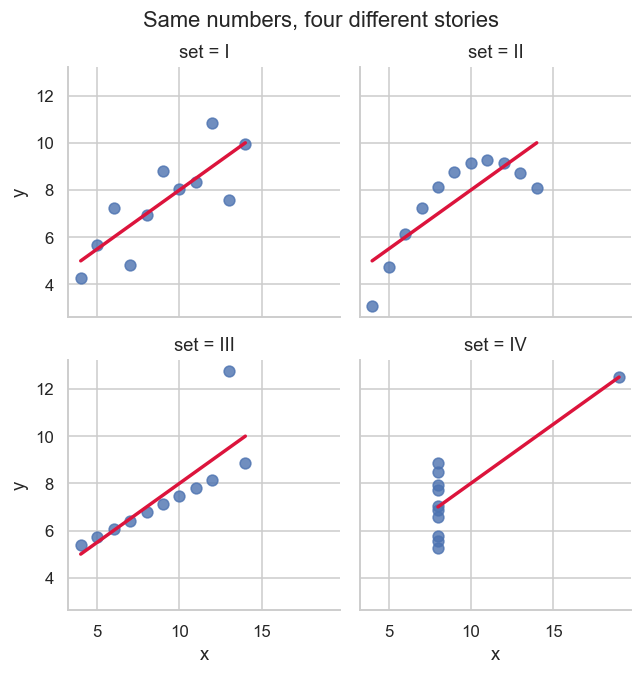

In [4]:
g = sns.lmplot(data=anscombe, x="x", y="y", col="set", col_wrap=2, height=3, ci=None,
               scatter_kws={"s": 50}, line_kws={"color": "crimson"})
g.fig.suptitle("Same numbers, four different stories", y=1.02)
plt.show()

> 🎤 SAY: "Same mean, same SD, same correlation, same regression line — and four totally different realities.
> I: fine. II: a *curve* — a straight-line correlation is the wrong tool. III: one outlier is dragging the line. IV: one single point creates the whole correlation."
> 🎤 SAY: "**Summary numbers lie. EDA means LOOKING.** Today's four questions: What is the *shape*? What is *weird*? What is *related*? And *who are the groups*?"
> ⏱️ Keep this to ~3 min. It's a hook, not a lecture.

### 🎯 Today's mission
**Campus Wellbeing Survey** — 520 students, 4 programs. The Dean asks: *"What really drives exam performance?"*
We'll answer with 4 EDA moves: **shape → anomalies → relationships → groups.**

In [5]:
df = load("raw")        # the raw file, straight from the survey system
print(df.shape)
df.head(8)

(530, 13)


,student_id,program,year,age,residence,study_hours_week,sleep_hours,caffeine_cups_day,social_media_hours_day,part_time_job_hours_week,commute_minutes,stress_score,exam_score
0,CS-0400,Business,3,20,Hostel,18.0,8.8,0,0.7,0.0,13.0,2.2,73.2
1,CS-0507,Data Science,2,19,Hostel,19.0,6.9,0,0.8,4.0,9.0,3.1,58.5
2,CS-0449,Business,1,19,Hostel,16.7,8.0,1,4.0,0.0,11.0,7.2,71.6
3,CS-0489,Data Science,1,18,Hostel,11.0,7.3,2,1.8,0.0,12.0,4.3,62.5
4,CS-0014,Business,4,22,Hostel,10.6,5.1,2,3.4,0.0,7.0,2.5,64.1
5,CS-0313,Business,1,19,Hostel,10.6,7.0,2,1.3,0.0,8.0,4.0,72.4
6,CS-0254,Data Science,2,20,Commuter,25.9,7.8,1,3.7,7.0,93.0,5.6,70.8
7,CS-0011,DS,4,21,Commuter,15.6,4.6,2,3.6,23.0,152.0,6.2,46.5


| Column | Meaning |
|---|---|
| `program`, `year`, `age`, `residence` | who the student is |
| `study_hours_week`, `part_time_job_hours_week`, `commute_minutes` | how they spend time |
| `sleep_hours`, `caffeine_cups_day`, `social_media_hours_day`, `stress_score` (1–10) | habits & wellbeing |
| `exam_score` (0–100) | the outcome we care about |

---
## Part 1 · Distributions: what does each variable look like?

> **🕙 10:58 (17 min)**
> Goal: students learn to ask "what SHAPE is this?" before computing any average, and that a mean can describe nobody.

### 1.1 First look: `info()` and `describe()`

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                530 non-null    object 
 1   program                   530 non-null    object 
 2   year                      530 non-null    int64  
 3   age                       530 non-null    int64  
 4   residence                 530 non-null    object 
 5   study_hours_week          530 non-null    float64
 6   sleep_hours               481 non-null    float64
 7   caffeine_cups_day         530 non-null    int64  
 8   social_media_hours_day    530 non-null    float64
 9   part_time_job_hours_week  530 non-null    float64
 10  commute_minutes           530 non-null    float64
 11  stress_score              517 non-null    float64
 12  exam_score                530 non-null    float64
dtypes: float64(7), int64(3), object(3)
memory usage: 54.0+ KB


In [7]:
df.describe().round(1)

,year,age,study_hours_week,sleep_hours,caffeine_cups_day,social_media_hours_day,part_time_job_hours_week,commute_minutes,stress_score,exam_score
count,530.0,530.0,530.0,481.0,530.0,530.0,530.0,530.0,517.0,530.0
mean,2.5,20.8,20.5,6.8,1.9,2.9,6.8,37.4,5.8,66.8
std,1.1,12.7,43.9,1.4,1.6,1.2,8.4,34.8,2.0,42.4
min,1.0,5.0,1.0,-7.5,0.0,0.3,0.0,4.0,1.0,26.7
25%,2.0,19.0,12.4,6.1,1.0,2.2,0.0,12.0,4.6,57.1
50%,2.0,20.0,18.4,6.7,2.0,3.0,0.0,25.0,5.9,65.6
75%,3.0,21.0,24.0,7.4,3.0,3.7,14.0,52.0,7.2,73.7
max,4.0,250.0,999.0,25.0,8.0,6.8,30.0,224.0,10.0,999.0


> 🎤 SAY: "Take 20 seconds. Look at the **min** and **max** rows. Don't say anything yet — just *notice*. Write 2 suspicious things in your notes."
> (Wait 20 s.) 🎤 "Keep your list. In a few minutes you'll get 15 minutes alone with this raw file to hunt every problem. For now we'll look only at columns that look healthy."
> 👀 What they should have noticed: age max 250, study_hours max 999, sleep min -7.5 / max 25, exam max 999.

### 1.2 Shape: part-time job hours

### 🔮 PREDICT (answer in chat *before* running the next cell)


`part_time_job_hours_week` = hours per week a student works a paid job.

**What shape will the histogram have?** &nbsp; A) bell curve &nbsp; B) long right tail &nbsp; C) two humps

> 🎤 Take votes. Most will say A. That's the point.

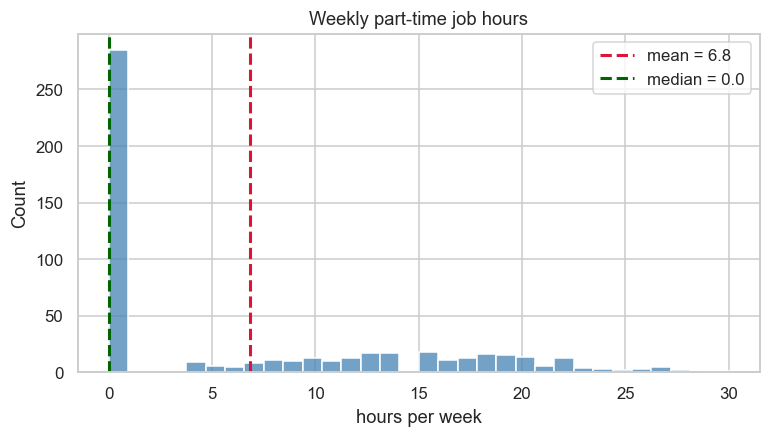

Share of students who do NOT work: 54 %


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["part_time_job_hours_week"], bins=32, ax=ax, color="steelblue")
mean, median = df["part_time_job_hours_week"].mean(), df["part_time_job_hours_week"].median()
ax.axvline(mean, color="crimson", ls="--", lw=2, label=f"mean = {mean:.1f}")
ax.axvline(median, color="darkgreen", ls="--", lw=2, label=f"median = {median:.1f}")
ax.set_title("Weekly part-time job hours"); ax.set_xlabel("hours per week"); ax.legend()
plt.show()
print("Share of students who do NOT work:", round((df["part_time_job_hours_week"] == 0).mean() * 100), "%")

> 🎤 SAY: "**Two humps** — a giant spike at zero (students who don't work) and a second cluster around 15 hours. This is a *bimodal* distribution — really **two populations** glued together."
> 🎤 SAY: "The mean is about 6.8 hours. **Is there a single student who works 6.8 hours?** Barely. The mean describes *nobody*. The median is 0, which is also misleading. Lesson: when you see two humps, **don't summarise — split**."
> ❓ Ask chat: "How would you report this to the Dean in one sentence?" (Expect: "about 55% don't work; those who do work ~15 hours".)

### 1.3 Shape: commute time (skew)

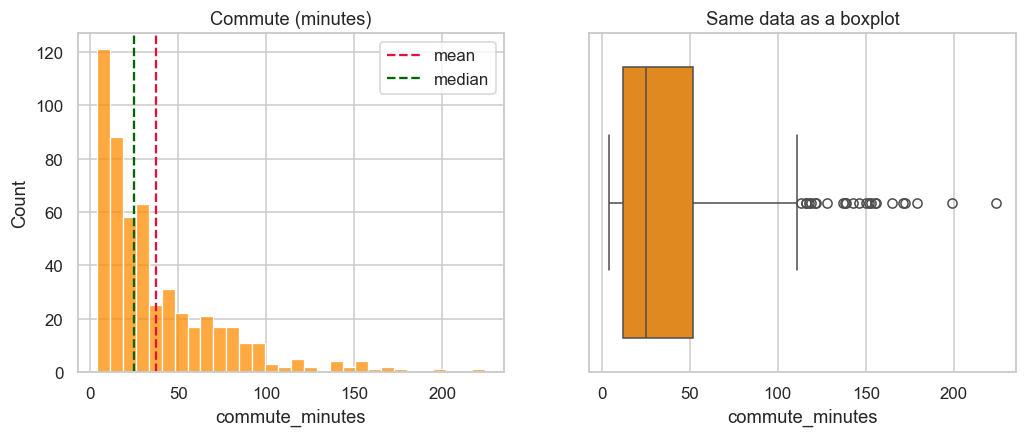

mean = 37.4   median = 25.0   skew = 1.87


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["commute_minutes"], bins=30, ax=axes[0], color="darkorange")
axes[0].axvline(df["commute_minutes"].mean(), color="crimson", ls="--", label="mean")
axes[0].axvline(df["commute_minutes"].median(), color="darkgreen", ls="--", label="median")
axes[0].set_title("Commute (minutes)"); axes[0].legend()
sns.boxplot(x=df["commute_minutes"], ax=axes[1], color="darkorange")
axes[1].set_title("Same data as a boxplot")
plt.show()
print(f"mean = {df['commute_minutes'].mean():.1f}   median = {df['commute_minutes'].median():.1f}   skew = {df['commute_minutes'].skew():.2f}")

> 🎤 SAY: "Right-skewed: most commutes are short, a few are very long, so the **mean (37) is pulled above the median (25)**. For skewed data, report the **median**."
> 🎤 SAY: "The dots on the boxplot are Tukey outliers (beyond 1.5×IQR) from Class 1. **Are they errors?** A 3-hour commute is painful — but possible. *An outlier is a question, not a verdict.*"

### 1.4 Is the skew hiding a *mixture*?

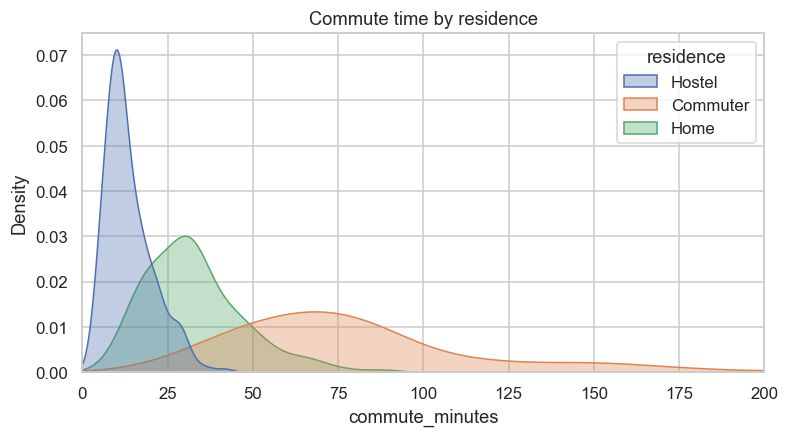

,count,median,mean
residence,,,
Commuter,154,71.0,78.5
Home,137,31.0,32.6
Hostel,239,12.0,13.6


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x="commute_minutes", hue="residence", common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_title("Commute time by residence"); ax.set_xlim(0, 200)
plt.show()
df.groupby("residence")["commute_minutes"].agg(["count", "median", "mean"]).round(1)

> 🎤 SAY: "Same trick as the job hours: the skewed shape is a **mixture of groups**. Hostel students walk 10 minutes, commuters travel over an hour. *Splitting by a category often explains a weird shape.* Remember this — it's the main idea of Part 3."
> (✂️ Cut this section if you are behind.)

### 🙋 Your turn (90 seconds)

Make a histogram of `social_media_hours_day`. **In chat, type 3 words describing its shape** (symmetric? skewed? two humps?).

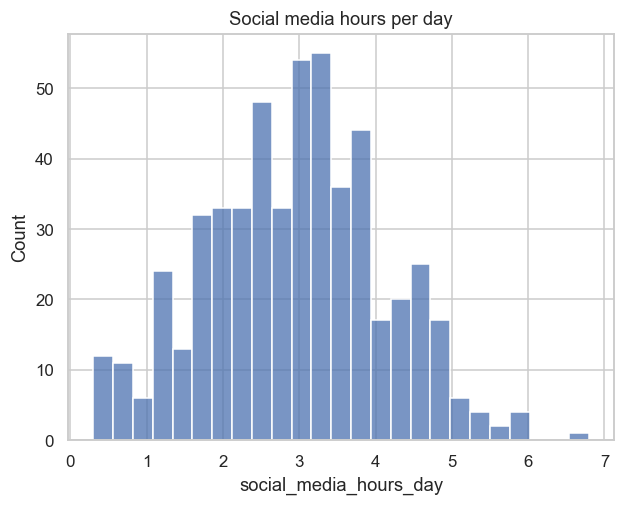

In [11]:
sns.histplot(df["social_media_hours_day"], bins=25)
plt.title("Social media hours per day")
plt.show()

> 🎤 Expect: "roughly symmetric / bell-shaped / centred around 3 hours". Call on two students to say it aloud. Quick win: *not every variable is weird.*
> ➡️ **Transition (11:13):** "Now it's your turn. Open **notebook 03 — Data Detective**. You have 15 minutes, alone. Cameras on, mics muted, `?` in chat if stuck."

---
## 🕵️ Solo task: Data Detective

👉 Open **`03_STUDENT_solo_data_detective.ipynb`** (link in chat). 15 minutes, individual. We'll continue here afterwards.

> **🕙 11:15–11:35 (15 min work + 5 debrief)** — see `03_INSTRUCTOR_solo_solutions.ipynb` for the answer key.
> 👩‍💻 While they work: stay on camera, answer chat, and ask a TA / strong student to help with `?` messages. Post a timer in chat at the 10-min and 2-min marks.
> 🏁 **Debrief (5 min):**
> 1. Ask: "How many problems did you find? Type the number in chat." (Anyone ≥ 8 gets a shout-out.)
> 2. Ask **2–3 volunteers to share their screen** and show their best finding.
> 3. Reveal the full list from notebook 03-INSTRUCTOR.
> 4. 🎤 SAY: "The most important decision wasn't deleting the bad rows — it was deciding to **KEEP** the students who study 55+ hours. An outlier is not an error. Check before you delete."

---
## Part 2 · Relationships & Correlation

> **🕙 11:35 (17 min)** — From now on we use the **clean** file so everybody is looking at the same numbers.

In [12]:
df = load("clean")
print(df.shape, "→ duplicates removed, labels fixed, impossible values blanked (NaN)")
df.isna().sum()[lambda s: s > 0]

(520, 13) → duplicates removed, labels fixed, impossible values blanked (NaN)


age                  3
study_hours_week     2
sleep_hours         49
stress_score        13
exam_score           2
dtype: int64

### 2.1 Correlation vocabulary
| \|r\| | Say |
|---|---|
| < 0.2 | very weak / none |
| 0.2 – 0.4 | weak–moderate |
| 0.4 – 0.7 | moderate–strong |
| > 0.7 | strong |

**Pearson r only measures *straight-line* association** (remember Anscombe II!).

### 🔮 PREDICT (answer in chat *before* running the next cell)


We'll draw a **correlation heatmap** of all numeric columns, and `exam_score` is the outcome we care about.

**Chat:** which ONE variable do you think has the *strongest positive* link with exam score?

> 🎤 Expect: study hours (most), sleep. Don't reveal.

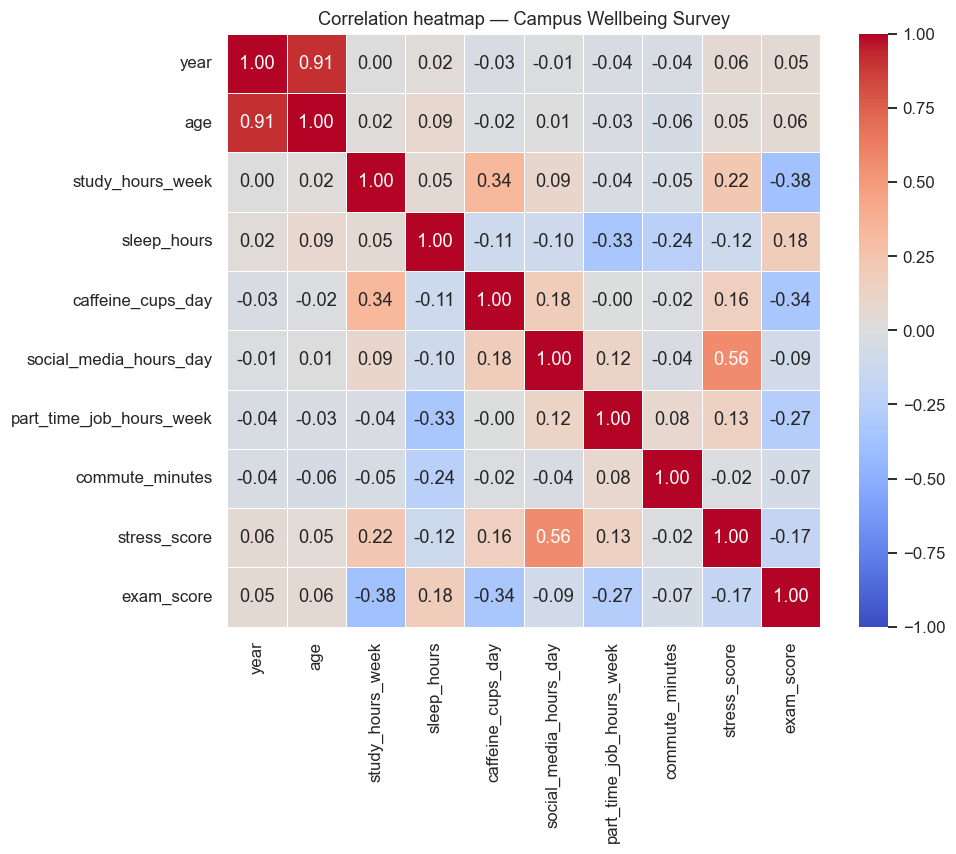

In [13]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation heatmap — Campus Wellbeing Survey")
plt.show()

> 🎤 SAY: "Read the heatmap like a map: **red = move together, blue = move opposite, white = unrelated.** Look at the `exam_score` row."
> Walk through, ~3 min:
> • `age`–`year` = 0.91 → obvious/trivial (don't get excited about it).
> • `social_media_hours_day`–`stress_score` ≈ 0.56 → the strongest *interesting* link.
> • `exam_score` vs `study_hours_week` = **−0.38**. 😱 Pause here. "Negative?! Studying *lowers* scores?" Park it: "Hold that thought, we'll solve it after the break."
> • `exam_score` vs `caffeine_cups_day` = −0.34. (Team 4 will investigate.)
> • `exam_score` vs `sleep` +0.18 and vs `job hours` −0.27.

### 2.2 Correlation ≠ causation

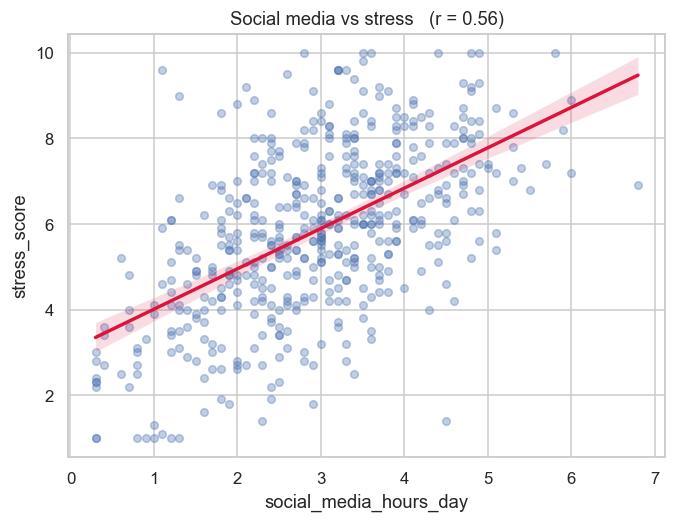

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=df, x="social_media_hours_day", y="stress_score",
            scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "crimson"}, ax=ax)
r = df["social_media_hours_day"].corr(df["stress_score"])
ax.set_title(f"Social media vs stress   (r = {r:.2f})")
plt.show()

### 🔮 PREDICT (answer in chat *before* running the next cell)


Social media and stress clearly move together (r ≈ 0.56).

**Vote:** A) social media causes stress &nbsp; B) stress makes students scroll more &nbsp; C) something else drives both &nbsp; D) can't tell from this data

> 🎤 Answer: D (and A, B, C are all plausible). Correlation gives **association, not direction.** Use the words 'is associated with', never 'causes'.

> 🎤 SAY: "Three reasons two things correlate: **(1) A causes B, (2) B causes A, (3) a hidden C causes both** — or (4) pure coincidence. A scatter plot can't tell them apart. Experiments or careful design can."
> (✂️ Cut the poll if you are behind — just say it.)

### 2.3 The cliffhanger: study hours vs exam score

### 🔮 PREDICT (answer in chat *before* running the next cell)


Students who study **more** should score **higher**, right?

**Chat:** will the scatter plot slope **up**, **down**, or be **flat**?

> 🎤 Everyone says 'up'. You already saw −0.38 on the heatmap, so say nothing — let them commit.

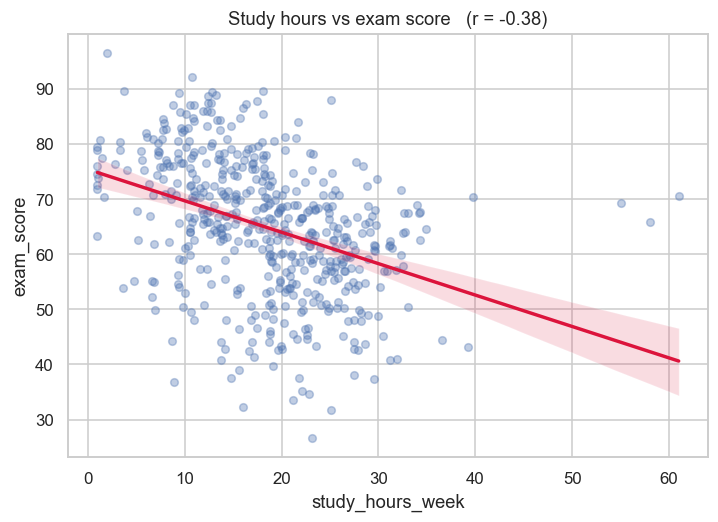

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.regplot(data=df, x="study_hours_week", y="exam_score",
            scatter_kws={"alpha": 0.35, "s": 25}, line_kws={"color": "crimson"}, ax=ax)
r = df["study_hours_week"].corr(df["exam_score"])
ax.set_title(f"Study hours vs exam score   (r = {r:.2f})")
plt.show()

> 🎤 SAY: "**Down.** The more students study, the *lower* they score. So — should the Dean tell students to study less?"
> (Let them react in chat for 20 seconds.)
> 🎤 SAY: "Something is off. Write down ONE hypothesis for why this might be wrong. We'll test it right after the break."
> ☕ **Break at ~11:52** — "7 minutes. Be back at 11:59 sharp. Cameras off, stretch."

---
## ☕ Break — 7 minutes
*While you're away, think: what could make studying look harmful when it isn't?*

---
## Part 3 · Grouping: *who* is in the data?

> **🕙 11:59 (13 min) — the climax of the class.** Welcome them back; ask 2 students for their hypothesis from before the break.

### 3.1 Split the data with `groupby`

In [16]:
by_program = df.groupby("program").agg(
    students=("student_id", "count"),
    avg_study_hours=("study_hours_week", "mean"),
    avg_exam_score=("exam_score", "mean"),
).round(1).sort_values("avg_study_hours", ascending=False)
by_program

,students,avg_study_hours,avg_exam_score
program,,,
Engineering,143,26.2,54.6
Data Science,138,20.7,61.4
Business,156,14.0,70.1
Design,83,8.7,78.9


> 🎤 SAY: "Look carefully. Engineering studies the most (≈26 h) and scores the lowest (≈55). Design studies the least (≈9 h) and scores the highest (≈78). **The programs differ in *both* study time and score.** What if programs, not study hours, are driving the negative line?"

### 3.2 Same scatter plot — now coloured by program

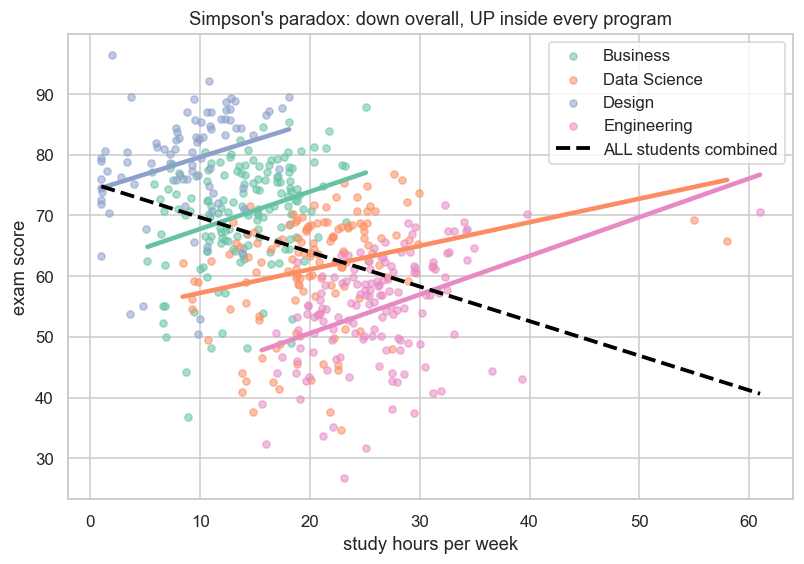

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
palette = dict(zip(sorted(df["program"].unique()), sns.color_palette("Set2", 4)))
for prog, g in df.dropna(subset=["study_hours_week", "exam_score"]).groupby("program"):
    ax.scatter(g["study_hours_week"], g["exam_score"], s=22, alpha=0.55, color=palette[prog], label=prog)
    slope, intercept = np.polyfit(g["study_hours_week"], g["exam_score"], 1)
    xs = np.linspace(g["study_hours_week"].min(), g["study_hours_week"].max(), 10)
    ax.plot(xs, intercept + slope * xs, color=palette[prog], lw=3)
all_ = df.dropna(subset=["study_hours_week", "exam_score"])
slope, intercept = np.polyfit(all_["study_hours_week"], all_["exam_score"], 1)
xs = np.linspace(all_["study_hours_week"].min(), all_["study_hours_week"].max(), 10)
ax.plot(xs, intercept + slope * xs, color="black", ls="--", lw=2.5, label="ALL students combined")
ax.set_xlabel("study hours per week"); ax.set_ylabel("exam score")
ax.set_title("Simpson's paradox: down overall, UP inside every program")
ax.legend()
plt.show()

> 🎤 SAY (pause for effect): "**Inside every single program, more study = higher score.** The black dashed line — all students combined — points the *opposite way*. That's **Simpson's paradox**."
> 🎤 SAY: "Why: the programs are *different* (harder grading, more demanding), so they sit at different heights. Engineering students study the most and score the lowest *because of the program*, not because studying is harmful."
> Famous real example: the 1973 UC Berkeley admissions data — overall it looked like women were admitted less; department by department, women were admitted at equal or higher rates.

### 3.3 The numbers behind the picture

In [18]:
rows = {"ALL students": df["study_hours_week"].corr(df["exam_score"])}
for prog, g in df.groupby("program"):
    rows[prog] = g["study_hours_week"].corr(g["exam_score"])
pd.Series(rows, name="correlation (study vs exam)").round(2).to_frame()

,correlation (study vs exam)
ALL students,-0.38
Business,0.30
Data Science,0.28
Design,0.28
Engineering,0.40


### 🔮 PREDICT (answer in chat *before* running the next cell)


**Final question for the Dean.** Based on what you now know, vote:

A) "Tell students to study less." &nbsp; B) "Keep encouraging study — the negative trend is an illusion." &nbsp; C) "Compare students only *within* the same program."

(You can pick more than one.)

> 🎤 Best answers: B and C. 🎤 SAY: **Rule #1 of EDA: always ask 'who are the groups?' before believing an overall trend.** An average across different groups can say the opposite of every group.

### 🎁 Bonus (if time): program × year heatmap

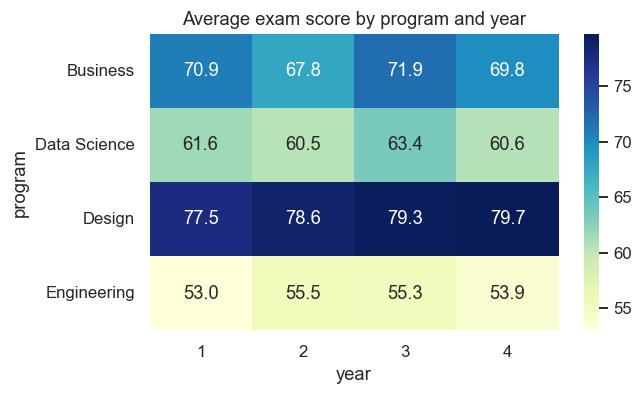

In [19]:
pivot = df.pivot_table(index="program", columns="year", values="exam_score", aggfunc="mean").round(1)
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set_title("Average exam score by program and year")
plt.show()

> ✂️ Skip if behind. 🎤 "A pivot table is `groupby` with two keys. Notice: **year barely matters; program matters a lot** — consistent with our story."
> **➡️ Transition (12:12):** "Now YOU become the detectives in teams. Open notebook **04**. Your team number is in chat. I'm opening breakout rooms."

---
## 👥 Team missions

👉 Open **`04_STUDENT_team_mission.ipynb`**, set `TEAM = <your number>`, and follow your mission card. **11 minutes** in your breakout room, then a **45-second pitch**.

> **🕙 12:12–12:25 (13 min)** — see `INSTRUCTOR_TEAM_GUIDE.md` + `04_INSTRUCTOR_team_answers.ipynb`.
> 1. *(before 12:12)* Post the notebook link and team assignment in chat. Pre-create 5 breakout rooms with 5 students each.
> 2. Read the roles out loud: **Driver** (shares screen, types) · **Skeptic** ("what else could explain this?") · **Spokesperson** (45-sec pitch) · **Timekeeper** · **Scribe** (writes pitch in the notebook).
> 3. Open rooms. At 4 min and 8 min broadcast: "Chart done? Now write the recommendation." Visit 2–3 rooms; each visit ask: "What's the one chart that proves your point?"
> 4. At 12:23 close rooms with a 60-second warning.

---
## 🏁 Wrap-up: the 4 laws of EDA

1. **Look before you summarise** — means and correlations can hide the real shape (Anscombe).
2. **An outlier is a question, not a verdict** — investigate before deleting (error vs real signal).
3. **Correlation is linear and not causal** — check shape, direction, and hidden third variables.
4. **Always ask "who are the groups?"** — overall trends can reverse inside the groups (Simpson).

**Exit ticket (type in chat):** *What was your biggest surprise today?*

> **🕙 12:25 (5 min)** — Pitches: each team gets 45 s — *"Headline · one piece of evidence · one recommendation."* Don't screen share; speak. After each: one sentence of praise + one pushback question from `INSTRUCTOR_TEAM_GUIDE.md`.
> 🏆 Pick the winner: "the team that connected their chart to a *decision*".
> 🎤 Close: "Nobody pays you to write `sns.histplot`. They pay you to look at data, find what's weird, and tell humans what to do about it. Great class."
> **Optional homework:** pick any dataset you like (Kaggle, your own life) and write **5 EDA findings**, each with one chart and one sentence starting with "This is associated with…".